In [59]:
import pyterrier as pt
import ir_datasets
import os
import matplotlib.pyplot as plt
from owi.owi import ir_datasets_owi

In [60]:
pt.init()
ir_datasets_owi.register()

RuntimeError: You can only call <function legacy_init at 0x000001F5C17E91C0> before either you start using java or call pt.java.init()

In [61]:
#ds = pt.get_dataset("irds:disks45/nocr/trec-robust-2004")
ds = pt.get_dataset("irds:owi/subsampled/dev")
print(ds)

INDEX_DIR = "./new_owi_index_customfeatures"
os.makedirs(INDEX_DIR, exist_ok=True)

INDEX_DIR = os.path.abspath("./new_owi_index_customfeatures")

IRDSDataset('owi/subsampled/dev')


## new index part

load index

In [115]:
index = pt.IndexFactory.of(INDEX_DIR)

21:27:15.215 [main] INFO org.terrier.structures.FSADocumentIndex -- Document index requires 1,4 MiB remaining heap is 3,7 GiB
21:27:15.343 [main] INFO org.terrier.structures.BaseCompressingMetaIndex -- Structure meta reading lookup file into memory
21:27:15.355 [main] INFO org.terrier.structures.BaseCompressingMetaIndex -- Structure meta reading reverse map for key docno directly from disk
21:27:15.357 [main] WARN org.terrier.structures.BaseCompressingMetaIndex -- Structure meta reading data file directly from disk (SLOW) - try index.meta.data-source=fileinmem in the index properties file. 589,4 MiB of memory would be required.


create index

In [116]:
# META_FIELD_LENGTHS = {"docno": 65, "main_content": 10000}
# INDEXER_PROPERTIES = {"meta.reverse.keys": "docno,main_content"}

# indexer = pt.IterDictIndexer(
#     INDEX_DIR,
#     text_attrs = ['main_content'],
#     meta = META_FIELD_LENGTHS,
#     properties = INDEXER_PROPERTIES
# )

# index_ref = indexer.index(ds.get_corpus_iter())
# index = pt.IndexFactory.of(index_ref)

In [ ]:
print(index.getCollectionStatistics())

Number of documents: 357212
Number of terms: 3932782
Number of postings: 94259835
Number of fields: 0
Number of tokens: 562115239
Field names: []
Positions:   false



In [118]:
meta_index = index.getMetaIndex()

print(meta_index.getKeys())
print(list(meta_index.getReverseKeys()))

['docno', 'main_content']
['docno']


## XG Boost Part

In [119]:
import os
import pyterrier as pt
import pandas as pd
import xgboost as xgb
import re

In [120]:
#Function 1
def count_term_in_body_unique(row, meta_index):
    """
    Counts how many unique terms in the query appear in the document body.
    """
    docno = row["docno"]
    docid = meta_index.getDocument("docno", docno)

    if docid == -1:
        return 0

    body = meta_index.getItem("main_content", docid)

    body_terms = set(body.lower().split())
    query_terms = set(row["query"].lower().split())

    count = sum(1 for term in query_terms if term in body_terms)
    return count

In [121]:
#Function 2
def count_term_in_body_full(row, meta_index):
    """
    Counts the total occurrences of query terms in the document body.
    """
    docno = row["docno"]
    docid = meta_index.getDocument("docno", docno)

    if docid == -1:
        return 0

    body = meta_index.getItem("main_content", docid) or ""

    body_terms = body.lower().split()
    query_terms = row["query"].lower().split()

    # Count total occurrences
    count = sum(body_terms.count(term) for term in query_terms)
    return count

In [122]:
#Function3 
def query_coverage_first_200(row, meta_index):
    docno = row["docno"]
    docid = meta_index.getDocument("docno", docno)
    if docid == -1:
        return 0.0
    
    body = meta_index.getItem("main_content", docid) or ""

    body_terms = body.lower().split()[:200]
    query_terms = row["query"].lower().split()
    if not query_terms:
        return 0.0
    
    matched_terms = sum(1 for term in query_terms if term in body_terms)
    return float(matched_terms / len(query_terms))


In [123]:
#Fuction 4 
def count_doc_length(row, meta_index):
    """
    Counts the total number of words in the document body.
    """
    docno = row["docno"]
    docid = meta_index.getDocument("docno", docno)

    if docid == -1:
        return 0

    body = meta_index.getItem("main_content", docid) or ""

    return len(body.split())

In [124]:
#Function 5 
def count_query_length(row, meta_index=None):
    """
    Counts the total number of words in the query.
    """
    query = row["query"] or ""
    return len(query.split())

In [125]:
#Function 6 
def query_document_length_ratio(row, meta_index):
    """
    Computes the ratio: document_length / query_length.
    """
    docno = row["docno"]
    docid = meta_index.getDocument("docno", docno)

    if docid == -1:
        return 0

    body = meta_index.getItem("main_content", docid) or ""
    doc_length = len(body.split())

    query = row["query"] or ""
    query_length = len(query.split())

    if query_length == 0:
        return 0

    return doc_length / query_length

In [126]:
#Function 7 
def first_query_term_position(row, meta_index):
    """
    Returns the first position (0-based index) of any query term in the document body.
    """
    docno = row["docno"]
    docid = meta_index.getDocument("docno", docno)

    if docid == -1:
        return -1

    body = meta_index.getItem("main_content", docid) or ""
    body_terms = body.lower().split()

    query_terms = set(row["query"].lower().split())

    for i, term in enumerate(body_terms):
        if term in query_terms:
            return i

    return -1

In [127]:
from sentence_transformers import SentenceTransformer

sbert_minilm = SentenceTransformer("all-MiniLM-L6-v2")
sbert_mpnet = SentenceTransformer("all-mpnet-base-v2")

In [128]:
import numpy as np
def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

In [129]:
def cosine_bert_minilm(row, meta_index):
    docno = row["docno"]
    docid = meta_index.getDocument("docno", docno)
    if docid == -1:
        return 0.0
    
    body = meta_index.getItem("body", docid) or ""
    query = row.get("query","")
    
    body_emb = sbert_minilm.encode(body)
    query_emb = sbert_minilm.encode(query)
    
    return cosine_sim(query_emb,body_emb)
def cosine_bert_mpnet(row, meta_index):
    docno = row["docno"]
    docid = meta_index.getDocument("docno", docno)
    if docid == -1:
        return 0.0
    
    body = meta_index.getItem("body", docid) or ""
    query = row.get("query","")
    
    body_emb = sbert_mpnet.encode(body)
    query_emb = sbert_mpnet.encode(query)
    
    return cosine_sim(query_emb,body_emb)

In [130]:
#Testing some functions on an example:
docid = 0
body = meta_index.getItem("main_content", docid)
docno = meta_index.getItem("docno", docid)

# print("DOCNO:", docno)
# print("BODY:", body[:300])

test_row = {
    "docno": docno,
    "query": "example query relative. the and"
}


count_unique = count_term_in_body_unique(test_row, meta_index)
print("\nNumber of unique query terms in document:", count_unique)

count_full = count_term_in_body_full(test_row, meta_index)
print("\nNumber of query terms in document in total:", count_full)


Number of unique query terms in document: 2

Number of query terms in document in total: 76


In [131]:
custom_feature_transformer_unique = pt.apply.doc_score(
    lambda row: count_term_in_body_unique(row, meta_index)
)

custom_feature_transformer_full = pt.apply.doc_score(
    lambda row: count_term_in_body_full(row, meta_index)
)

custom_feature_coverage_200 = pt.apply.doc_score(
    lambda row: query_coverage_first_200(row, meta_index)
)

custom_feature_coverage_doc_length = pt.apply.doc_score(
    lambda row: count_doc_length(row, meta_index)
)

custom_feature_coverage_query_length = pt.apply.doc_score(
    lambda row: count_query_length(row, meta_index)
)

custom_feature_ratio = pt.apply.doc_score(
    lambda row: query_document_length_ratio(row, meta_index)
)

custom_feature_first_match = pt.apply.doc_score(
    lambda row: first_query_term_position(row, meta_index)
)

custom_feature_minilm = pt.apply.doc_score(
    lambda row: cosine_bert_minilm(row, meta_index)
)

custom_feature_mpnet = pt.apply.doc_score(
    lambda row: cosine_bert_mpnet(row, meta_index)
)



In [ ]:
pt.terrier.set_property("index.meta.data-source", "fileinmem")   #for speed 
pt.terrier.set_property("indexer.meta.forward.keylens.docno", "65")
pt.terrier.set_property("indexer.meta.forward.keylens.main_content", "10000") 

topics = ds.get_topics().rename(columns={"title": "query"})
topics["query"] = topics["query"].apply(lambda x: re.sub(r'[^A-Za-z0-9 ]+', ' ', x))
qrels = ds.get_qrels()

qrels['label'] = qrels['label'] + 2  # Shift labels to make them non-negative

print(qrels.head())
print(qrels['label'].unique())

#train-validation split 
split = int(len(topics) * 0.8)
train_topics = topics.iloc[:split]
valid_topics = topics.iloc[split:]
train_qrels = qrels[qrels["qid"].isin(train_topics["qid"])]
valid_qrels = qrels[qrels["qid"].isin(valid_topics["qid"])]

#base retrievers
pt.logging("INFO")
bm25 = pt.terrier.Retriever(index, wmodel="BM25")
#tf = pt.terrier.Retriever(index_ref, wmodel="Tf")    
pl2 = pt.terrier.Retriever(index, wmodel="PL2")  

#candiate retrieval using base retrievers 
candidate_retrieval = (bm25 % 100) #| (pl2 % 100) #| (tf % 100) |

bm25_scorer = pt.terrier.Retriever(index, wmodel="BM25")
tf_scorer = pt.terrier.Retriever(index, wmodel="Tf")
pl2_scorer = pt.terrier.Retriever(index, wmodel="PL2")


features = []

pipeline = (candidate_retrieval 
            >> pt.text.get_text(index, "main_content") 
            >>  (
                bm25_scorer 
                ** tf_scorer
                ** pl2_scorer 
                ** custom_feature_transformer_unique 
                ** custom_feature_transformer_full
                ** custom_feature_coverage_200
                ** custom_feature_coverage_doc_length
                ** custom_feature_coverage_query_length
                ** custom_feature_ratio
                ** custom_feature_first_match
                )
            )

xgb_ranker = xgb.XGBRanker(
    objective="rank:ndcg",
    learning_rate=0.1,
    gamma=1.0,
    min_child_weight=0.1,
    max_depth=6,
    random_state=42
)

  qid                                              docno  label iteration
0   3  0434be636200bec94cf9c9267d83a314db5ed66f7daa04...      2        Q0
1   3  0613590b24db271a692b0e0eea44ce4ac48080d5c230d7...      4        Q0
2   3  1ddb8e93d2259c719bd72ea589132b4b3368e72cb2dac6...      3        Q0
3   3  1f2c20f36169182cf77aa08b14657783fb2caffc48d211...      2        Q0
4   3  2a5b6bb9235b3ada7e1ee8328b3bb035303ec962ce1183...      2        Q0
[2 4 3 5 0]


C:\Users\paulj\AppData\Local\Temp\ipykernel_26400\2234934829.py:22: DeprecationWarning: Call to deprecated function (or staticmethod) set_log_level. (use pt.java.set_log_level(...) instead) -- Deprecated since version 0.11.0.
  pt.logging("INFO")


In [ ]:
ltr_model = xgb.XGBRanker()
ltr_model.load_model("ltr_pipeline_rmv_tf_terful_ql.json")
#ltr_pipeline = pipeline >> pt.ltr.apply_learned_model(ltr_model, form="ltr")
ltr_pipeline = pipeline >> pt.ltr.apply_learned_model(xgb_ranker, form="ltr")

ltr_pipeline.fit(train_topics, train_qrels, valid_topics, valid_qrels)

ltr_pipeline_minilm = ltr_pipeline % 100 >> custom_feature_minilm
ltr_pipeline_mpnet = ltr_pipeline % 100 >> custom_feature_mpnet

bm25_pipline = pt.terrier.Retriever(index, wmodel="BM25")



21:27:20.077 [main] INFO org.terrier.querying.LocalManager -- Starting to execute query 3 - split ergo keyboard
21:27:20.079 [main] INFO org.terrier.querying.LocalManager -- running process TerrierQLParser
21:27:20.080 [main] INFO org.terrier.querying.LocalManager -- running process TerrierQLToControls
21:27:20.082 [main] INFO org.terrier.querying.LocalManager -- running process TerrierQLToMatchingQueryTerms
21:27:20.083 [main] INFO org.terrier.querying.LocalManager -- running process ApplyTermPipeline(termpipelines=Stopwords,PorterStemmer)
21:27:20.085 [main] INFO org.terrier.querying.LocalManager -- running process ApplyLocalMatching
21:27:20.087 [main] INFO org.terrier.querying.LocalManager -- split { req=null, w=1.0, stats=null, models=[org.terrier.matching.models.BM25@544820b7] tags=[firstmatchscore]} ergo { req=null, w=1.0, stats=null, models=[org.terrier.matching.models.BM25@6b98a075] tags=[firstmatchscore]} keyboard { req=null, w=1.0, stats=null, models=[org.terrier.matching.mo

In [134]:
# results = ltr_pipeline.transform(valid_topics)

# #results.to_csv("ltr_results_nn.csv", index=False)
# print(results.head(10))

In [ ]:
# Weight: Number of times a feature is used in splits.
# Gain: Average improvement in the loss function when the feature is used.
# Cover: Average number of samples affected by splits using the feature.

print(ltr_pipeline[-1].transform)

skle = ltr_pipeline[-1].learner
xgboo = skle.get_booster()
xgboo.feature_names = ["bm25",
                       "TF",
                       "PL2",
                       "term_unique",
                       "term_full",
                       "term_first200",
                       "doc_length",
                       "query_length", 
                       "ratio", 
                       "first_match",
                    ]


<bound method RegressionTransformer.transform of <pyterrier.ltr.LTRTransformer object at 0x000001F668D34380>>


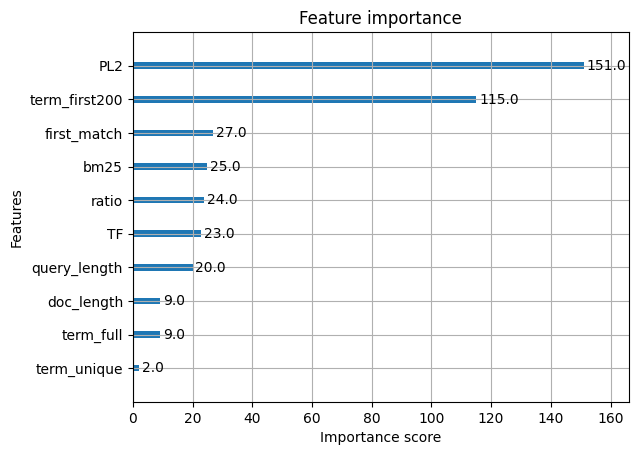

In [136]:
xgb.plot_importance(xgboo,importance_type = "weight")
plt.show()   

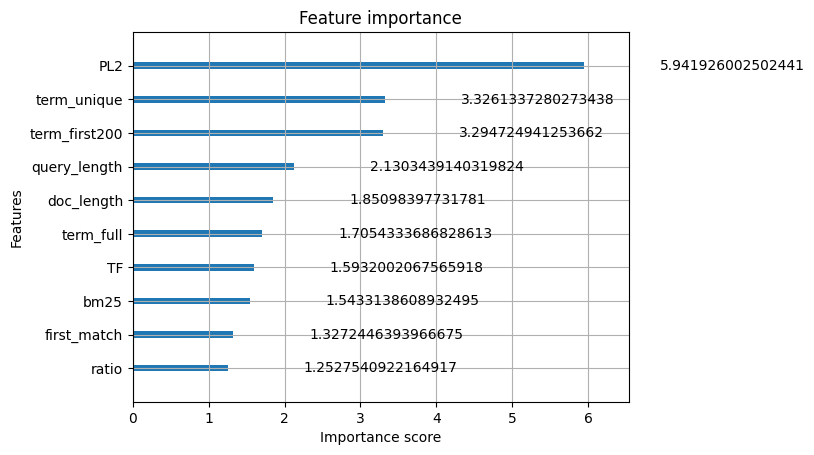

In [137]:
xgb.plot_importance(xgboo,importance_type = "gain")
plt.show()

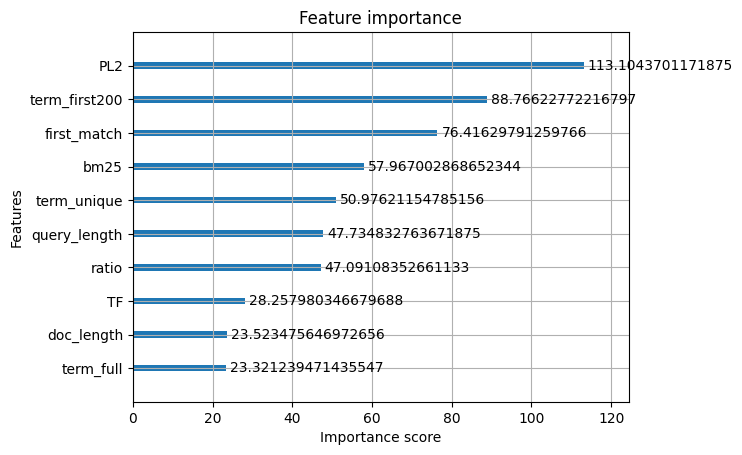

In [138]:
xgb.plot_importance(xgboo,importance_type = "cover")
plt.show()   

In [144]:
evalution = pt.Experiment([ltr_pipeline],valid_topics,valid_qrels, eval_metrics=["map", "ndcg_cut_10"])

21:28:56.248 [main] INFO org.terrier.querying.LocalManager -- Starting to execute query 58 - growth of esports industry
21:28:56.249 [main] INFO org.terrier.querying.LocalManager -- running process TerrierQLParser
21:28:56.250 [main] INFO org.terrier.querying.LocalManager -- running process TerrierQLToControls
21:28:56.251 [main] INFO org.terrier.querying.LocalManager -- running process TerrierQLToMatchingQueryTerms
21:28:56.252 [main] INFO org.terrier.querying.LocalManager -- running process ApplyTermPipeline(termpipelines=Stopwords,PorterStemmer)
21:28:56.253 [main] INFO org.terrier.querying.LocalManager -- running process ApplyLocalMatching
21:28:56.254 [main] INFO org.terrier.querying.LocalManager -- growth { req=null, w=1.0, stats=null, models=[org.terrier.matching.models.BM25@4bff1903] tags=[firstmatchscore]} esport { req=null, w=1.0, stats=null, models=[org.terrier.matching.models.BM25@62dae540] tags=[firstmatchscore]} industri { req=null, w=1.0, stats=null, models=[org.terrier.

In [145]:
print(evalution)

                                                name       map  ndcg_cut_10
0  (TerrierRetr(BM25) >> RankCutoff(500) >> <pyte...  0.307326     0.671144


In [141]:
df_eval = pd.DataFrame(evalution)
excel_path = "owi_evaluation_results.xlsx"
sheet_name = "owi_Results"

if os.path.exists(excel_path):
    existing = pd.read_excel(excel_path, sheet_name=sheet_name)
    combined = pd.concat([existing, df_eval], ignore_index=True)
    combined.to_excel(excel_path, sheet_name=sheet_name, index=False)
else:
    df_eval.to_excel(excel_path, sheet_name=sheet_name, index=False)

print(eval)   

<built-in function eval>
